In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'
%reload_ext lab_black

In [2]:
import matplotlib.pyplot as plt
import random
import numpy as np
import seaborn as sns
import pickle

sns.set_context("talk")
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.colors import ListedColormap
from scipy.stats import pearsonr


from loren_frank_data_processing import (
    get_multiunit_dataframe,
    get_multiunit_dataframe2,
)

from src.load_data import load_data
from src.parameters import ANIMALS
from ZilongCode.utils import (
    get_steps,
    get_diffusion_exponent,
)

### 1, plot theta sequence example and replay sequence example

In [ ]:
epoch_key = ("bon", 8, 4)
data = load_data(epoch_key)

In [ ]:
datafolder = (
    "/home/zilong/Desktop/AdaptiveAttractorForSequences/ExpData/ThetaSweepTrajectories"
)

animal, day, epoch = epoch_key
# load the classifier results
cv_classifier_clusterless_results = xr.open_dataset(
    os.path.join(
        datafolder,
        f"{animal}_{day:02d}_{epoch:02d}_cv_classifier_clusterless_results.nc",
    )
)

# get all time slice
t = data["position_info"].index / np.timedelta64(1, "s")

# load multiunit times
multiunit_times = [
    get_multiunit_dataframe(tetrode_key, ANIMALS)
    for tetrode_key in data["tetrode_info"].index
]
if multiunit_times[0] is None:
    multiunit_times = [
        get_multiunit_dataframe2(tetrode_key, ANIMALS)
        for tetrode_key in data["tetrode_info"].index
    ]
# reset index in multiunit_times to seconds and replace the original multiunit_times
for i in range(len(multiunit_times)):
    indext_i = multiunit_times[i].index / np.timedelta64(1, "s")
    multiunit_times[i].index = indext_i

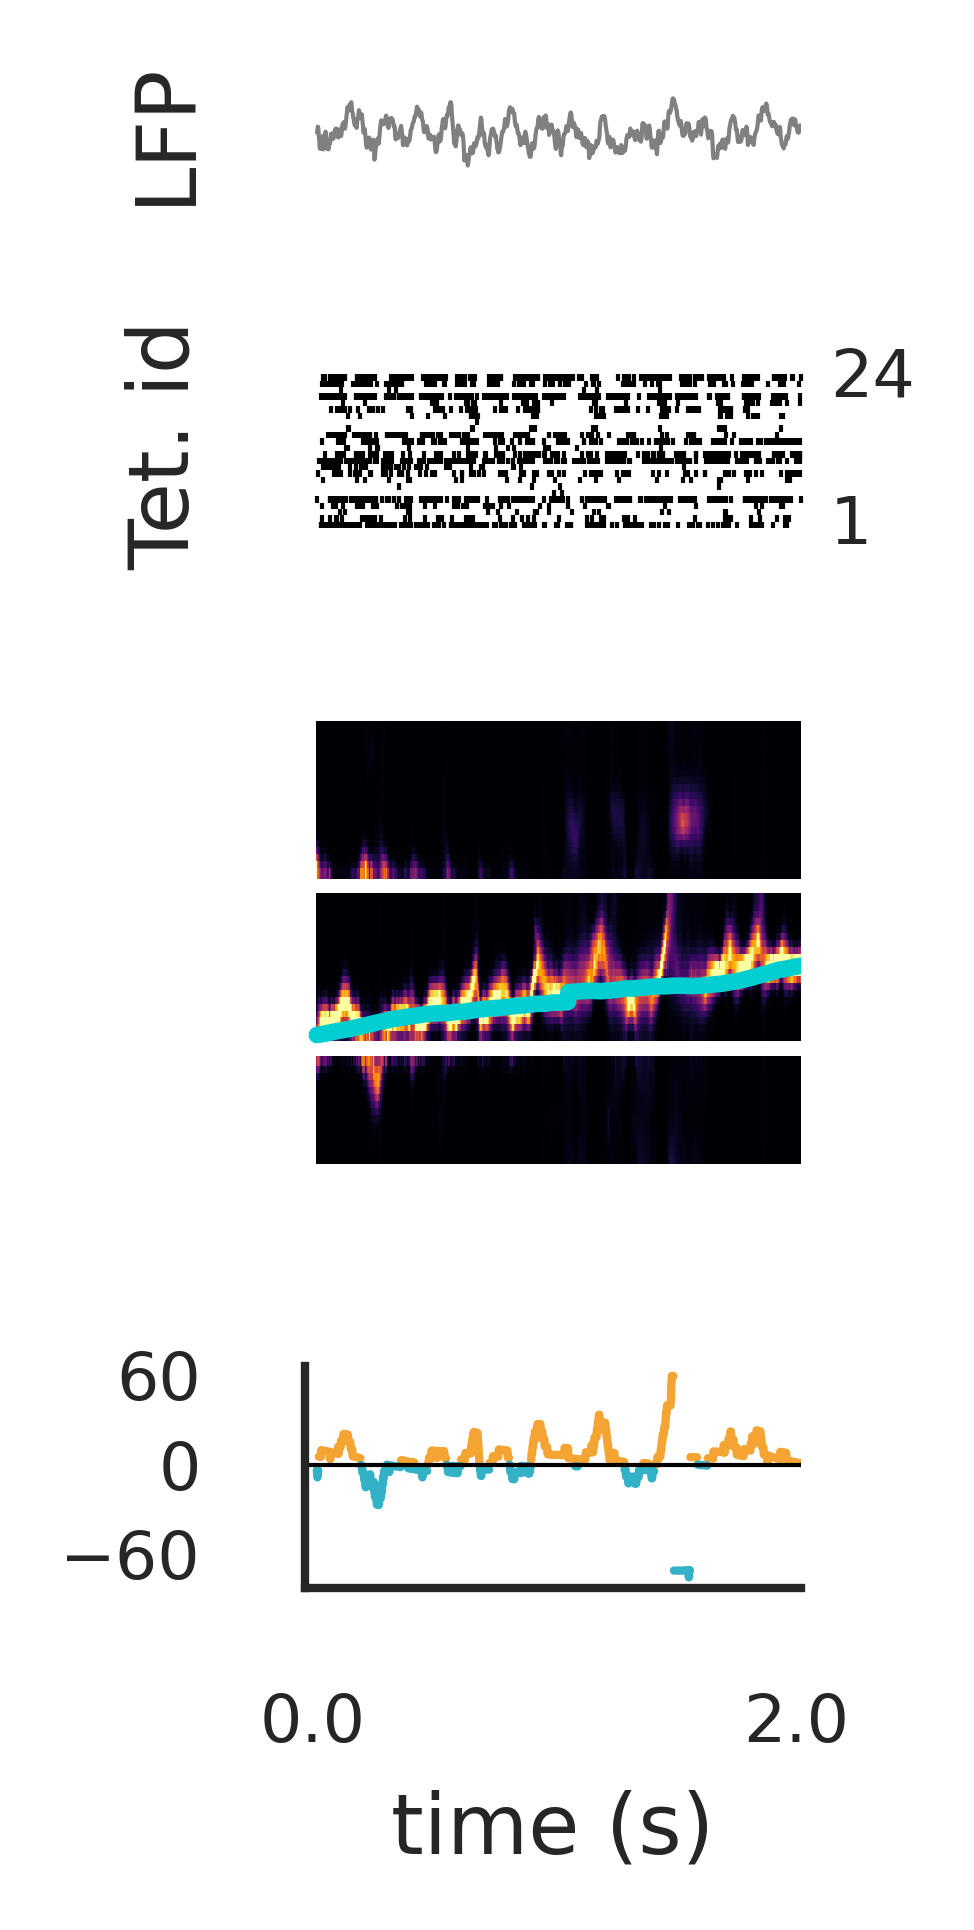

In [ ]:
def plot_theta_examples(time_slice_sweep, t, multiunit_times, results, data):

    """
    Modified from https://github.com/edeno/replicate_kenny_analysis/blob/master/notebooks/Bond_day8_Epoch4.ipynb
    by Zilong, 30/08/2023
    plor the theta sweeps in time_slice
    Input:
        time_slice: the time slice to plot
        t: the time index
        results: the results from the model
        data: the data from the model
        add_zero_phase_index: whether to add the zero phase index
    Output:
        a plot with 3 subplots
    """

    cmap = plt.cm.inferno
    cmap.set_bad("white", alpha=1.0)
    labelsize = 10
    ticksize = 8
    # set background color to white
    sns.set_style("white")

    fig = plt.figure(figsize=(2, 3.5), dpi=300)

    gs = gridspec.GridSpec(4, 1, height_ratios=[0.5, 1, 3, 1.5])

    ax1 = plt.subplot(gs[0, 0])

    ind = 0
    lfp = (
        data["lfps"]
        .reset_index(drop=True)
        .set_index(data["lfps"].index / np.timedelta64(1, "s"))
    )

    # plot as curve, not fill
    ax1.plot(
        lfp.loc[time_slice_sweep].index.values,
        lfp.loc[time_slice_sweep].iloc[:, ind].values.squeeze(),
        color="grey",
        linewidth=0.5,
    )
    ax1.set_ylabel("LFP")

    # remove xticks
    ax1.set_xticks([])
    # remove y ticks
    ax1.set_yticks([])

    # ax2
    ax2 = plt.subplot(gs[1, 0])

    n_tetrodes = len(multiunit_times)

    # eventplot with small dot
    ax2.eventplot(
        [multiunit.loc[time_slice_sweep].index for multiunit in multiunit_times],
        color="black",
        clip_on=False,
        linewidths=0.5,
    )

    ax2.set_yticks((1, n_tetrodes))
    # move the y ticks to right
    ax2.yaxis.tick_right()
    # remove y tick bars
    ax2.tick_params(axis="y", length=0)
    ax2.set_ylim((1, n_tetrodes))
    ax2.set_ylabel("Tet. id")
    ax2.set_xticks([])
    sns.despine(ax=ax2, offset=5)
    ax2.spines["bottom"].set_visible(False)

    # ax 3
    ax3 = plt.subplot(gs[2, 0])
    # plot
    results["acausal_posterior"].sum("state", skipna=False).sel(
        time=time_slice_sweep
    ).plot(
        x="time",
        y="position",
        robust=True,
        ax=ax3,
        cmap=cmap,
        vmin=0.0,
    )

    ax3.plot(
        data["position_info"].reset_index().set_index(t).loc[time_slice_sweep].index,
        data["position_info"]
        .reset_index()
        .set_index(t)
        .loc[time_slice_sweep]
        .linear_position,
        color="darkturquoise",
        linestyle="-",
        linewidth=2,
        alpha=1,
    )

    # remove all labels, ticks and spines in axi, as well as colorbars
    ax3.set_xlabel("")
    ax3.set_ylabel("")
    ax3.set_xticks([])
    ax3.set_yticks([])
    ax3.spines["right"].set_visible(False)
    ax3.spines["top"].set_visible(False)
    ax3.spines["left"].set_visible(False)
    ax3.spines["bottom"].set_visible(False)
    ax3.collections[0].colorbar.remove()

    # ax4
    ax4 = plt.subplot(gs[3, 0])
    # results.mental_distance_from_actual_position.sel(time=time_slice_sweep).plot(
    #     x="time", ax=ax4, color="#F18D00", linewidth=1, alpha=0.8
    # )

    # plot results.mental_distance_from_actual_position__ahead_behind.sel(time=time_slice_sweep)
    # with positive values as blue curve and negative values as orange curve with mask
    selected_data = results.mental_distance_from_actual_position_ahead_behind.sel(
        time=time_slice_sweep
    )
    selected_data.where(selected_data > 0).plot(
        x="time", ax=ax4, color="#F18D00", linewidth=1, alpha=0.8
    )
    selected_data.where(selected_data < 0).plot(
        x="time", ax=ax4, color="#009FB9", linewidth=1, alpha=0.8
    )

    # add a reference line at y=0 as black dashed line
    ax4.axhline(0, color="black", linestyle="-", linewidth=0.5)

    # set y label as 'Offset' and x label empty
    ax4.set_ylabel("", fontsize=labelsize)
    ax4.set_xlabel("time (s)", fontsize=labelsize)
    # set ticks off
    ax4.set_yticks([-60, 0, 60])
    # set x ticks with time_slice_sweep.start and time_slice_sweep.stop, keep one decimal
    ax4.set_xticks(
        [np.round(time_slice_sweep.start, 1), np.round(time_slice_sweep.stop, 1)]
    )
    # tick labels without scientific notation
    ax4.ticklabel_format(useOffset=False, style="plain")
    # set tick font size as ticksize
    ax4.tick_params(labelsize=ticksize)

    # set x ticks with time_slice_sweep.start and time_slice_sweep.stop, keep one decimal
    ax4.set_xticks(
        [np.round(time_slice_sweep.start, 1), np.round(time_slice_sweep.stop, 1)]
    )

    # set x ticklabels by subtrcting time_slice_sweep.start from time_slice_sweep.stop
    ax4.set_xticklabels(
        [
            np.round(time_slice_sweep.start - time_slice_sweep.start, 1),
            np.round(time_slice_sweep.stop - time_slice_sweep.start, 1),
        ]
    )

    # add ripple times to the plot as red bars on top of the LFP
    # first get the ripples time within the time slice
    for i in data["ripple_times"].index:
        # get the ripple time
        ripple_time = data["ripple_times"].iloc[i - 1]
        start_time = ripple_time.loc["start_time"] / np.timedelta64(1, "s")
        end_time = ripple_time.loc["end_time"] / np.timedelta64(1, "s")
        # if start_time and end_time are both in the time slice. then add the ripple to the plot
        # x range is start_time to end_time, y range is [0,300]
        if start_time > time_slice_sweep.start and end_time < time_slice_sweep.stop:
            ax3.axvspan(
                start_time, end_time, ymin=0, ymax=1, color="grey", alpha=0.6, lw=0
            )
            ax4.axvspan(
                start_time, end_time, ymin=0, ymax=1, color="grey", alpha=0.3, lw=0
            )

    # set ticks and spines
    all_axes = fig.get_axes()
    for ax in all_axes:
        ax.tick_params(labelsize=ticksize)
        ax.xaxis.label.set_size(labelsize)
        ax.yaxis.label.set_size(labelsize)
        # set axes off bottom left top and right
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlim(time_slice_sweep.start - 0.05, time_slice_sweep.stop)
        ax.yaxis.set_label_coords(-0.2, 0.5)

    # add back ax4 bottom and left spines
    ax4.spines["bottom"].set_visible(True)
    ax4.spines["left"].set_visible(True)
    # set axis linewidth 1.0
    ax4.spines["bottom"].set_linewidth(1.0)
    ax4.spines["left"].set_linewidth(1.0)

    # align y labels of ax1 and ax2

    plt.tight_layout()

    # save the figure to /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/Paper_figures/
    savedir = "/home/zilong/Desktop/AdaptiveAttractorForSequences/Figures/"

    savename = "Fig_replay_vs_theta_sequences_thetasweepexample.pdf"
    plt.savefig(savedir + savename, dpi=300, bbox_inches="tight")


time_slice = slice(t.min(), t.max())  # 107-117
time_slice_sweep = slice(t.min() + 243.5, t.min() + 245.5)
plot_theta_examples(
    time_slice_sweep,
    t,
    multiunit_times,
    cv_classifier_clusterless_results,
    data,
)

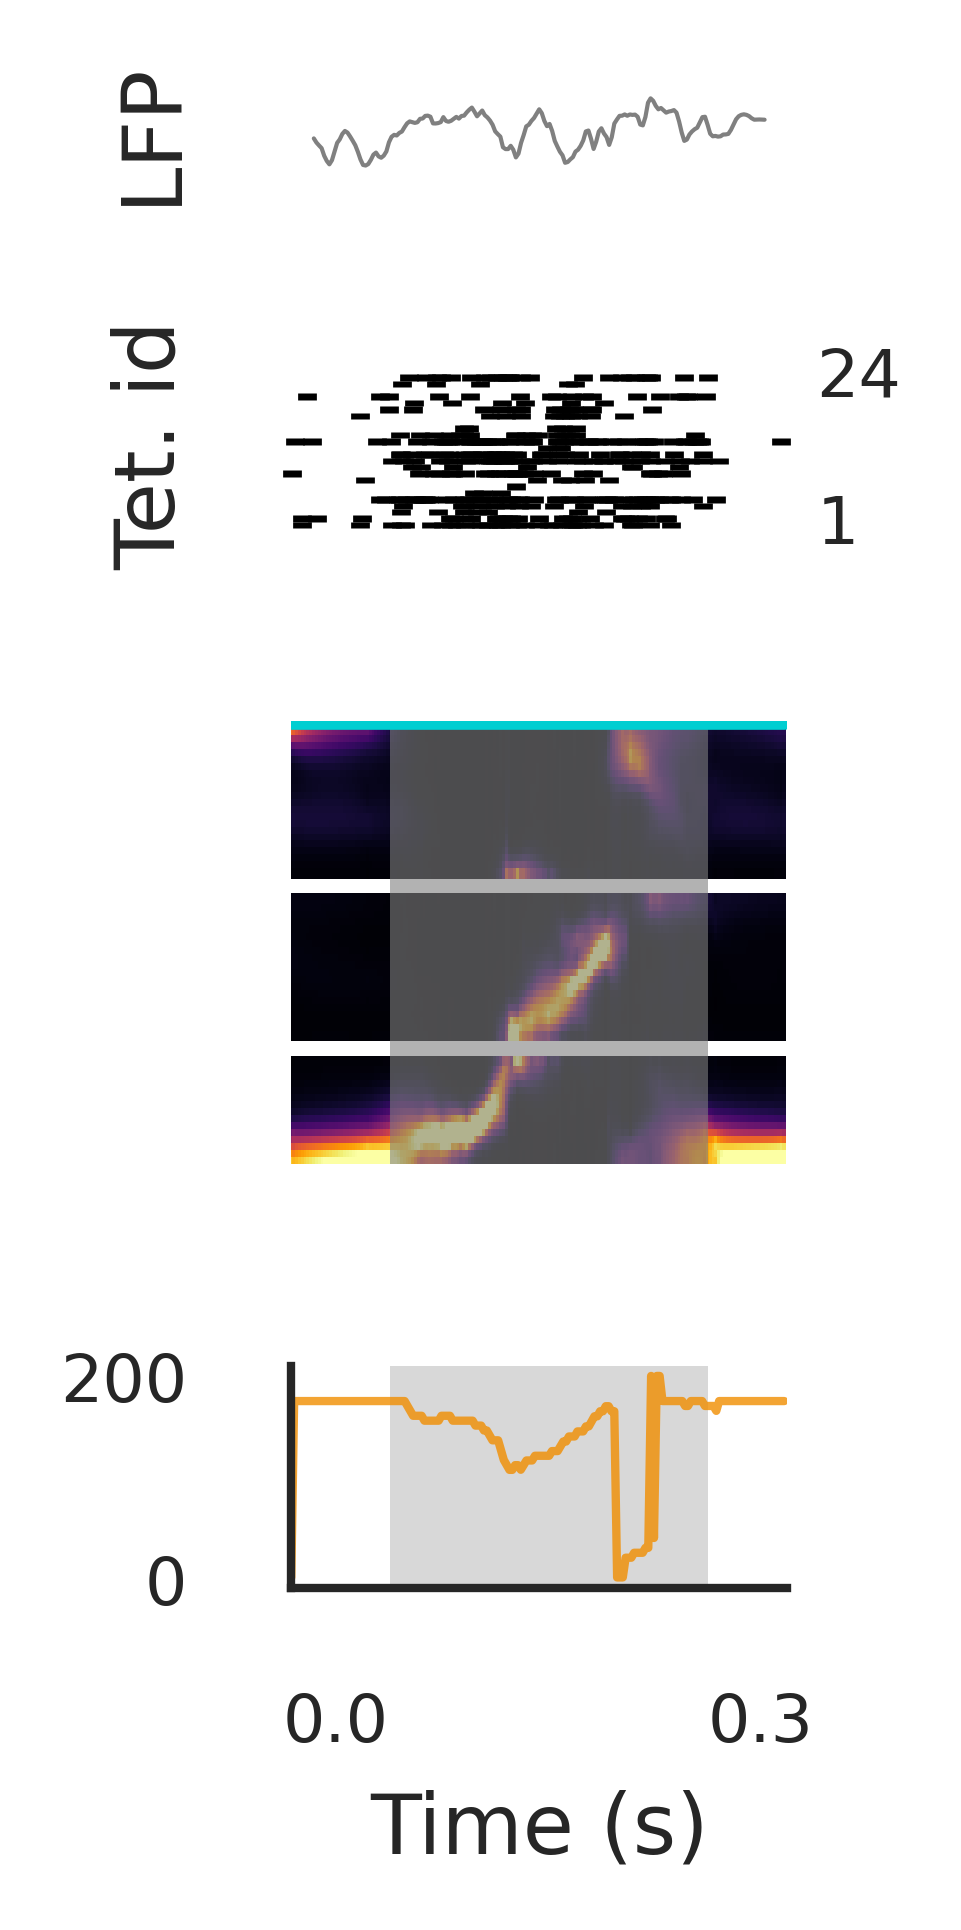

In [ ]:
def plot_replay_trajectory(
        time_slice_replay, t, multiunit_times, results, data, figsize=(8, 3)
):

    """
    Modified from https://github.com/edeno/replicate_kenny_analysis/blob/master/notebooks/Bond_day8_Epoch4.ipynb
    by Zilong, 30/08/2023
    plor the theta sweeps in time_slice
    Input:
        time_slice_replay: the time slice to plot. a list
        t: the time index
        results: the results from the model
        data: the data from the model
        add_zero_phase_index: whether to add the zero phase index
    Output:
    """

    cmap = plt.cm.inferno
    cmap.set_bad("white", alpha=1.0)
    labelsize = 10
    ticksize = 8
    # set background color to white
    sns.set_style("white")

    fig = plt.figure(figsize=figsize, dpi=300)

    cols = len(time_slice_replay)
    gs = gridspec.GridSpec(4, cols, height_ratios=[0.5, 1, 3, 1.5])

    for i in range(cols):

        time_slice_replay_i = time_slice_replay[i]

        ax5 = plt.subplot(gs[0, i])
        ind = 0
        lfp = (
            data["lfps"]
            .reset_index(drop=True)
            .set_index(data["lfps"].index / np.timedelta64(1, "s"))
        )

        # plot as curve, not fill
        ax5.plot(
            lfp.loc[time_slice_replay_i].index.values,
            lfp.loc[time_slice_replay_i].iloc[:, ind].values.squeeze(),
            color="grey",
            linewidth=0.5,
        )
        ax5.set_ylabel("LFP")

        # remove xticks
        ax5.set_xticks([])
        # remove y ticks
        ax5.set_yticks([])

        ax3 = plt.subplot(gs[1, i])

        n_tetrodes = len(multiunit_times)

        ax3.eventplot(
            [multiunit.loc[time_slice_replay_i].index for multiunit in multiunit_times],
            color="black",
            clip_on=False,
        )

        ax3.set_yticks((1, n_tetrodes))
        ax3.set_ylim((1, n_tetrodes))
        ax3.set_ylabel("Tet. id")
        ax3.set_xticks([])
        sns.despine(ax=ax3, offset=5)
        ax3.spines["bottom"].set_visible(False)

        # move the y ticks to right
        ax3.yaxis.tick_right()
        # remove y tick bars
        ax3.tick_params(axis="y", length=0)

        ax0 = plt.subplot(gs[2, i])
        # plot
        results["acausal_posterior"].sum("state", skipna=False).sel(
            time=time_slice_replay_i
        ).plot(
            x="time",
            y="position",
            robust=True,
            ax=ax0,
            cmap=cmap,
            vmin=0.0,
        )

        ax0.plot(
            data["position_info"]
            .reset_index()
            .set_index(t)
            .loc[time_slice_replay_i]
            .index,
            data["position_info"]
            .reset_index()
            .set_index(t)
            .loc[time_slice_replay_i]
            .linear_position,
            color="darkturquoise",
            linestyle="-",
            linewidth=2,
            alpha=1,
        )

        # remove all labels, ticks and spines in axi, as well as colorbars
        ax0.set_xlabel("")
        ax0.set_ylabel("")
        ax0.set_yticks([])
        ax0.set_xticks([])
        ax0.spines["right"].set_visible(False)
        ax0.spines["top"].set_visible(False)
        ax0.spines["left"].set_visible(False)
        ax0.spines["bottom"].set_visible(False)
        ax0.collections[0].colorbar.remove()

        # ax1
        ax1 = plt.subplot(gs[3, i])
        results.mental_distance_from_actual_position.sel(time=time_slice_replay_i).plot(
            x="time", ax=ax1, color="#F18D00", linewidth=1, alpha=0.8
        )
        # set y label as 'Offset' and x label empty
        ax1.set_ylabel("", fontsize=labelsize)
        ax1.set_xlabel("Time (s)", fontsize=labelsize)
        # set ticks off
        ax1.set_yticks([0, 200])
        # set x ticks with time_slice_replay.start and time_slice_replay.stop without scientific notation
        ax1.set_xticks(
            [
                np.round(time_slice_replay_i.start, 1),
                np.round(time_slice_replay_i.stop, 1),
            ]
        )
        # tick labels without scientific notation
        ax1.ticklabel_format(useOffset=False, style="plain")
        # set tick labels
        ax1.set_xticklabels(
            [
                np.round(time_slice_replay_i.start - time_slice_replay_i.start, 1),
                np.round(time_slice_replay_i.stop - time_slice_replay_i.start, 1),
            ],
            fontsize=ticksize,
        )
        # set tick font size as ticksize
        ax1.tick_params(labelsize=ticksize)

        # add ripple times to the plot as red bars on top of the LFP
        # first get the ripples time within the time slice
        for k in data["ripple_times"].index:
            # get the ripple time
            ripple_time = data["ripple_times"].iloc[k - 1]
            start_time = ripple_time.loc["start_time"] / np.timedelta64(1, "s")
            end_time = ripple_time.loc["end_time"] / np.timedelta64(1, "s")
            # if start_time and end_time are both in the time slice. then add the ripple to the plot
            # x range is start_time to end_time, y range is [0,300]
            if (
                start_time > time_slice_replay_i.start
                and end_time < time_slice_replay_i.stop
            ):
                ax0.axvspan(
                    start_time, end_time, ymin=0, ymax=1, color="grey", alpha=0.6, lw=0
                )
                ax1.axvspan(
                    start_time, end_time, ymin=0, ymax=1, color="grey", alpha=0.3, lw=0
                )
        # add back ax1 bottom and left spines
        ax1.spines["bottom"].set_visible(True)
        ax1.spines["left"].set_visible(True)
        # set axis linewidth 1.0
        ax1.spines["bottom"].set_linewidth(1.0)
        ax1.spines["left"].set_linewidth(1.0)

        ax3.set_xlim(time_slice_replay_i.start, time_slice_replay_i.stop)
        ax0.set_xlim(time_slice_replay_i.start, time_slice_replay_i.stop)
        ax1.set_xlim(time_slice_replay_i.start, time_slice_replay_i.stop)

    # set ticks and spines
    all_axes = fig.get_axes()
    for ax in all_axes:
        ax.tick_params(labelsize=ticksize)
        ax.xaxis.label.set_size(labelsize)
        ax.yaxis.label.set_size(labelsize)
        # set axes off bottom left top and right
        ax.spines["bottom"].set_visible(False)
        ax.spines["left"].set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.yaxis.set_label_coords(-0.2, 0.5)

    ax1.spines["bottom"].set_visible(True)
    ax1.spines["left"].set_visible(True)

    plt.tight_layout()

    # save the figure to /home/zilong/Desktop/replay_trajectory_paper/Processed-Data/Paper_figures/
    savedir = "/home/zilong/Desktop/AdaptiveAttractorForSequences/Figures/"

    savename = "Fig_replay_vs_theta_sequences_replayexample.pdf"
    plt.savefig(savedir + savename, dpi=300, bbox_inches="tight")


time_slice_1 = slice(t.min() + 42.35, t.min() + 42.7)
# time_slice_2 = slice(t.min() + 89.45, t.min() + 89.9)
time_slice_3 = slice(t.min() + 509.45, t.min() + 509.9)
# time_slice_4 = slice(t.min() + 662.8, t.min() + 663.2)
# time_slice_5 = slice(t.min() + 866.3, t.min() + 866.7)

# time_slice_replay = [
#     time_slice_1,
#     # time_slice_2,
#     time_slice_3,
#     # time_slice_4,
#     # time_slice_5,
# ]

time_slice_replay = [time_slice_1]

plot_replay_trajectory(
    time_slice_replay,
    t,
    multiunit_times,
    cv_classifier_clusterless_results,
    data,
    figsize=(2, 3.5),
)